# Week 5 — Full Exploration Pipeline: ED Triage Feasibility

**Dataset:** `yaleemmlc_admissionprediction_triage.csv` — 55,121 ED encounters x 225 features (25 structured + 200 chief-complaint flags), target = `esi` (Emergency Severity Index, 1 = most urgent, 5 = least urgent).

**Pipeline:** load → profile (missingness, dtypes, outliers) → clean → visualise (data-quality dashboard) → rank a top-10 feature shortlist. This single notebook is the full, commented record behind the 3-page feasibility memo.


## 1 · Setup

In [1]:
# Run this cell first. These are the three libraries we use all week.
import numpy as np                 # numerical helpers (NaN, medians, etc.)
import pandas as pd                # tables / DataFrames — our main tool
import matplotlib.pyplot as plt    # plotting

# Let pandas show more of a wide table when we print it:
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 3.0.2


In [2]:
# ── Schema map ────────────────────────────────────────────────────────────────
# This dataset has ~225 columns, so we never list them by hand. We sort them into
# "families" once, then refer to the families by name for the rest of the week.

TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) .. 5 (least). Our triage label.

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Helper: from a wish-list of names, keep only the ones that really exist in df.
    # (A plain function instead of a lambda, so it is easy to read.)
    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # The ~200 chief-complaint columns all start with "cc_", so we find them by prefix:
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

In [3]:
# Reference ranges for general adult triage. Each entry is (low, high, unit).
# NOTE: temperature is in FAHRENHEIT in this dataset (≈98.6 normal), not Celsius!
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

## 2 · Load the raw data

In [4]:
from pathlib import Path
# Looks beside the notebook first (local/JupyterLab); falls back to the Colab Drive path.
_local = Path("yaleemmlc_admissionprediction_triage.csv")
_colab = Path("/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv")
RAW_PATH = _local if _local.exists() else _colab
if not RAW_PATH.exists():
    raise FileNotFoundError(f"Could not find {RAW_PATH}. Place the CSV beside this notebook, or mount Drive (Colab).")
raw = pd.read_csv(RAW_PATH, index_col=0)   # index_col=0 drops the unnamed export index column
df = raw.copy()
fam = classify_columns(df)
structured = [c for c in df.columns if not c.startswith("cc_")]
print(f"Loaded {df.shape[0]:,} encounters x {df.shape[1]} columns")

Loaded 55,121 encounters x 225 columns


## 3 · Profile the raw data
Missingness, dtypes, target balance, vital-sign distributions, demographics, and outliers — the evidence base for the feasibility verdict.

In [5]:
# .isna() marks every cell True/False for "is this missing?".
# GOAL: a percentage-missing per structured column, worst first, gaps only.

# TODO 1 — FRACTION MISSING PER COLUMN
# HINT: df[structured].isna() gives True/False; taking .mean() of True/False = the fraction missing.
missing_fraction = df[structured].isna().mean()      # <- replace: add .mean() to get one fraction per column

# TODO 2 — TURN INTO A PERCENTAGE, worst first
# HINT: multiply by 100 and .round(1), then .sort_values(ascending=False).
missing_percent = (missing_fraction * 100).round(1)
missing_percent = missing_percent.sort_values(ascending=False)

# TODO 3 — SHOW ONLY COLUMNS WITH GAPS
# HINT: filter a Series with a mask -> missing_percent[missing_percent > 0]
missing_percent[missing_percent > 0]

Series([], dtype: float64)

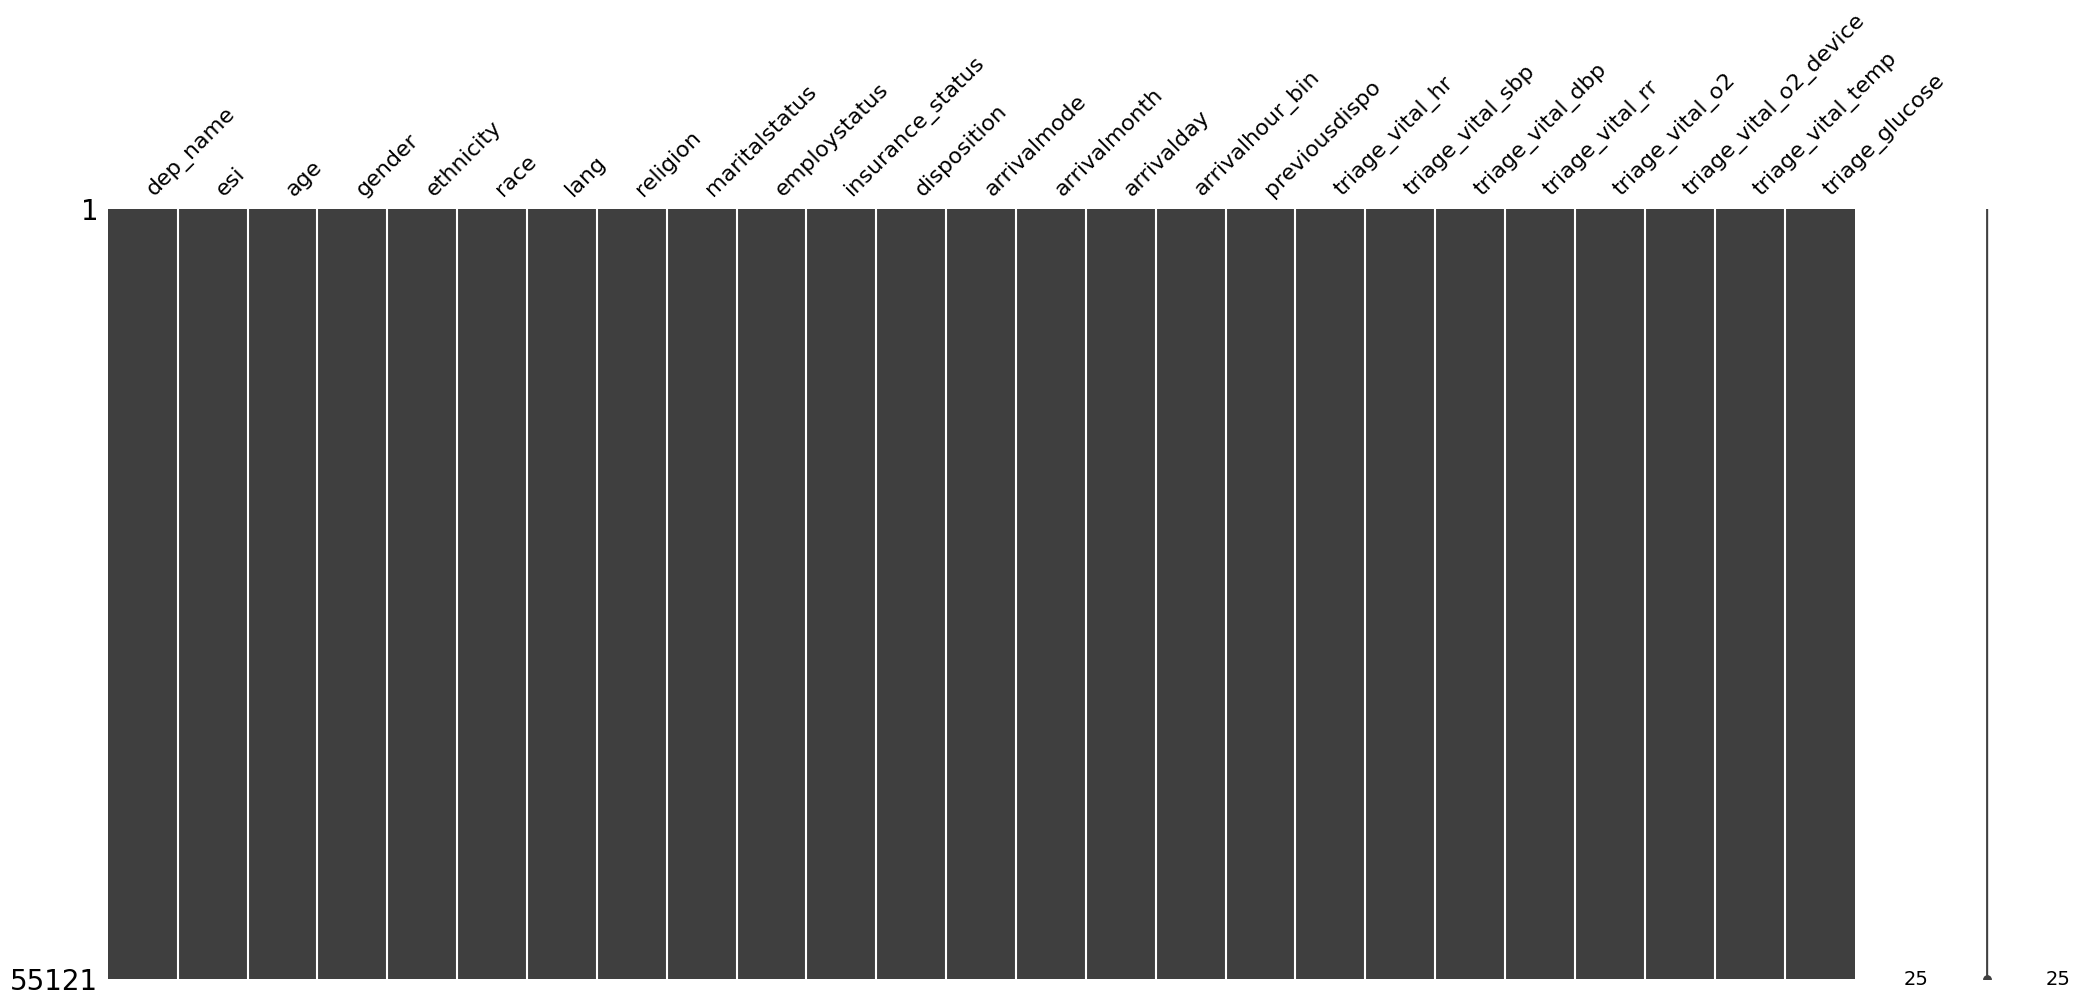

In [6]:
# Missingness map of the structured block (a 226-col map is unreadable)
try:
    import missingno as msno              # Colab: !pip install missingno -q
    msno.matrix(df[structured]); plt.show()
except Exception:
    fig, ax = plt.subplots(figsize=(11,4))
    ax.imshow(df[structured].isna().values, aspect="auto", cmap="gray_r")
    ax.set_xticks(range(len(structured))); ax.set_xticklabels(structured, rotation=90, fontsize=7)
    ax.set_title("Missing cells — structured columns (dark = missing)"); plt.tight_layout(); plt.show()

In [7]:
print(df[structured].dtypes)
print("\nESI value counts (raw):"); print(df[TARGET].value_counts(dropna=False).sort_index())

dep_name                      str
esi                       float64
age                       float64
gender                        str
ethnicity                     str
race                          str
lang                          str
religion                      str
maritalstatus                 str
employstatus                  str
insurance_status              str
disposition                   str
arrivalmode                   str
arrivalmonth                  str
arrivalday                    str
arrivalhour_bin               str
previousdispo                 str
triage_vital_hr           float64
triage_vital_sbp          float64
triage_vital_dbp          float64
triage_vital_rr           float64
triage_vital_o2           float64
triage_vital_o2_device    float64
triage_vital_temp         float64
triage_glucose            float64
dtype: object

ESI value counts (raw):
esi
1.0       77
2.0    17924
3.0    27010
4.0     8896
5.0     1214
Name: count, dtype: int64


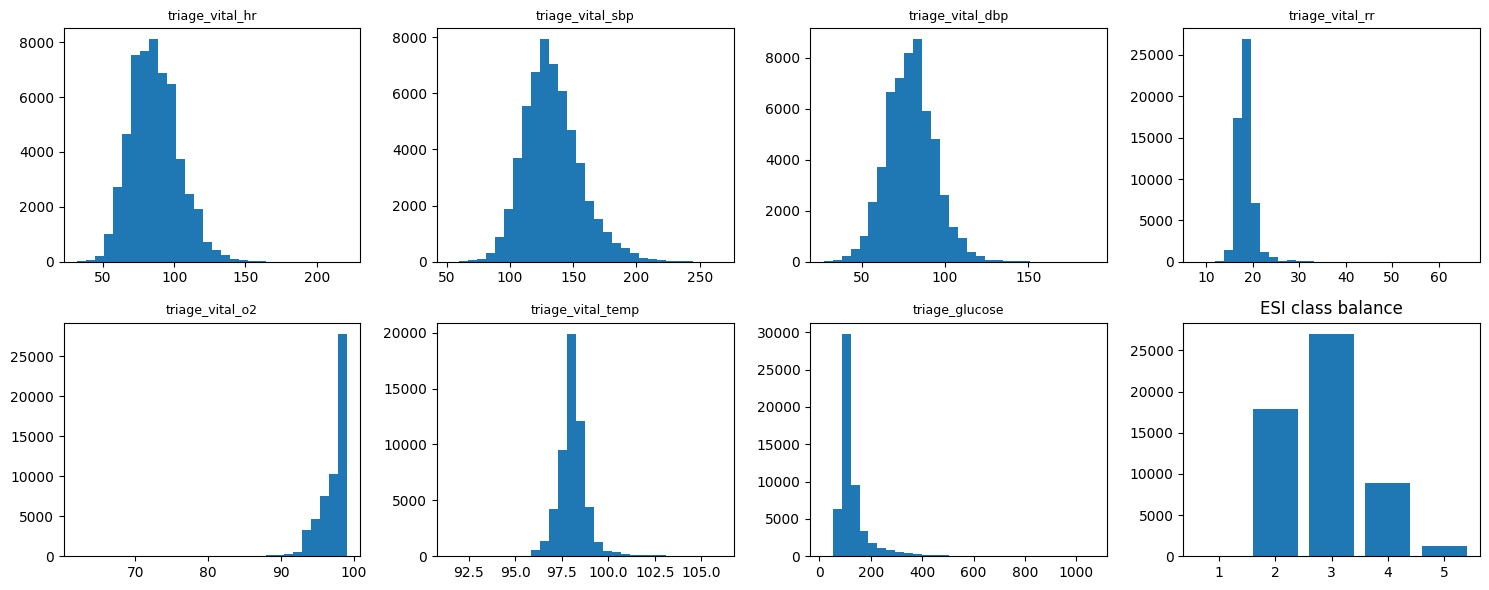

In [8]:
# Draw a histogram for each vital. (The instructor version also adds an ESI bar.)
vitals = fam["vitals"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
panels = axes.ravel()           # flatten the 2x4 grid into a list of 8 panels

for panel, col in zip(panels, vitals):
    # TODO: turn df[col] into numbers with pd.to_numeric(..., errors="coerce"), drop NaNs,
    #       then call panel.hist(values, bins=30) and panel.set_title(col).
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    panel.hist(values, bins=30)
    panel.set_title(col, fontsize=9)
    pass

esi_counts = df[TARGET].value_counts().sort_index()
panels[-1].bar(esi_counts.index, esi_counts.values)
panels[-1].set_title("ESI class balance")

plt.tight_layout(); plt.show()

In [9]:
# Demographics — the fairness-sensitive view (raw categories)
for c in ["race","ethnicity","insurance_status"]:
    print(c, "->", df[c].value_counts(dropna=False).to_dict())

race -> {'White or Caucasian': 29435, 'Black or African American': 15963, 'Other': 9016, 'Patient Refused': 370, 'Asian': 175, 'Unknown': 76, 'American Indian or Alaska Native': 66, 'Native Hawaiian or Other Pacific Islander': 20}
ethnicity -> {'Non-Hispanic': 45142, 'Hispanic or Latino': 9888, 'Patient Refused': 56, 'Unknown': 35}
insurance_status -> {'Medicaid': 21427, 'Medicare': 17581, 'Commercial': 14056, 'Other': 1883, 'Self pay': 174}


In [10]:
def outlier_report(df, col):
    """Count two kinds of outlier in one numeric column."""
    x = pd.to_numeric(df[col], errors="coerce").dropna()   # numbers only

    # TODO 1 — STATISTICAL OUTLIERS (the 1.5 x IQR "fence")
    # HINT: q1 = x.quantile(0.25); q3 = x.quantile(0.75); iqr = q3 - q1
    # HINT: count them with ((x < q1 - 1.5*iqr) | (x > q3 + 1.5*iqr)).sum()  -- keep the parentheses
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    low_fence = q1 - 1.5*iqr
    high_fence = q3 + 1.5*iqr
    iqr_outliers = ((x < low_fence) | (x > high_fence)).sum()

    # TODO 2 — CLINICALLY IMPOSSIBLE (outside the wide plausible bounds)
    # HINT: hard_low, hard_high = PLAUSIBLE.get(col, (-np.inf, np.inf))
    # HINT: count them with ((x < hard_low) | (x > hard_high)).sum()
    hard_low, hard_high = PLAUSIBLE.get(col, (-np.inf, np.inf))
    impossible = ((x < hard_low) | (x > hard_high)).sum()

    return {"iqr_outliers": iqr_outliers, "impossible": impossible}

report_rows = {}
for col in fam["vitals"]:
    report_rows[col] = outlier_report(df, col)
pd.DataFrame(report_rows).T

,iqr_outliers,impossible
triage_vital_hr,578,0
triage_vital_sbp,1028,0
triage_vital_dbp,726,0
triage_vital_rr,2366,4
triage_vital_o2,1505,0
triage_vital_temp,3554,0
triage_glucose,5673,25


In [11]:
# Make a numeric copy of the vitals so we can correlate them with ESI.
vitals_numeric = df[fam["vitals"]].copy()
for col in fam["vitals"]:
    vitals_numeric[col] = pd.to_numeric(vitals_numeric[col], errors="coerce")

# TODO 1 — VITALS vs ESI
# HINT: vitals_numeric.corrwith(df[TARGET]) gives one correlation per vital; .sort_values() orders them.
# HINT: print(vital_corr.round(3)) to read them (negative = tracks higher acuity).
vital_corr = vitals_numeric.corrwith(df[TARGET]).sort_values()
print("Vital vs ESI:")
print(vital_corr.round(3))

# TODO 2 — CHIEF COMPLAINTS vs ESI (they are already 0/1 numbers)
# HINT: df[fam["chief_complaints"]].corrwith(df[TARGET]).dropna().sort_values()
# HINT: .head(8) shows the 8 complaints most associated with LOW esi (high acuity).
cc_corr = df[fam["chief_complaints"]].corrwith(df[TARGET]).dropna().sort_values()
print("\n Chief Complaints vs ESI:")
print(cc_corr.head(8).round(3))


Vital vs ESI:
triage_vital_rr     -0.095
triage_vital_hr     -0.095
triage_glucose      -0.078
triage_vital_temp   -0.022
triage_vital_sbp     0.001
triage_vital_dbp     0.046
triage_vital_o2      0.178
dtype: float64



 Chief Complaints vs ESI:
cc_chestpain               -0.164
cc_shortnessofbreath       -0.150
cc_suicidal                -0.143
cc_alcoholintoxication     -0.142
cc_alteredmentalstatus     -0.132
cc_psychiatricevaluation   -0.103
cc_weakness                -0.081
cc_syncope                 -0.075
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 4 · Clean the data
Canonical Week-5 cleaning: drop rows with no `esi` label, coerce vitals to numeric, flag clinically impossible values as missing, impute (median for vitals, 0 for complaint flags, "Unknown" for blank categories), and round `esi` to a whole number.

In [12]:
import os
def clean_triage(raw):
    """Canonical Week-5 cleaning pipeline (the same steps you build in Tutorial 3).
    Takes the raw DataFrame and returns a cleaned copy."""
    d = raw.copy()
    fam = classify_columns(d)

    # 1. Drop rows with no triage label — we cannot learn a decision the data never recorded.
    d = d[d[TARGET].notna()].copy()

    # 2. Make the vital-sign columns (and age) numeric. Any stray text becomes NaN.
    numeric_cols = list(fam["vitals"])          # a copy of the vital-column list
    if "age" in d.columns:
        numeric_cols.append("age")
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # 3. Flag physiologically impossible values as missing (NaN) — do not "cap" them.
    for col in PLAUSIBLE:
        low, high = PLAUSIBLE[col]
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

    # 4. Fill the gaps. Vitals -> median (a robust middle value).
    for col in fam["vitals"]:
        d[col] = d[col].fillna(d[col].median())
    # A blank oxygen-device flag or chief-complaint flag means "not recorded" = 0.
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)
    for col in fam["chief_complaints"]:
        d[col] = d[col].fillna(0)
    # Text categories: a blank becomes the explicit category "Unknown".
    for col in fam["demographics"] + fam["admin"] + fam["leakage"]:
        if d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    # 5. The target should be a whole number 1-5, not a decimal.
    d[TARGET] = d[TARGET].round().astype(int)
    return d

In [13]:
CLEAN_PATH = Path("triage_cleaned_v1.csv")
df = clean_triage(raw)
fam = classify_columns(df)
df.to_csv(CLEAN_PATH)
print(f"Cleaned: {df.shape[0]:,} rows x {df.shape[1]} cols -> saved to {CLEAN_PATH}")

Cleaned: 55,121 rows x 225 cols -> saved to triage_cleaned_v1.csv


## 5 · Data-quality issues table
One row per measured problem — the same table that anchors the memo's 'top 3 concerns' section.

In [14]:
# One row per measured problem. Every number below was actually measured above,
# not assumed — this table is the evidence base for the Tutorial 5 memo.
issues = [
    {"issue": "Missing ESI label",
     "columns": "esi",
     "action": "None found in this extract (0/55,121) — rule stands for future refreshes: drop rows w/o target"},

    {"issue": "Missing structured values",
     "columns": "all 25 structured columns",
     "action": "None found (0% missing everywhere) — unusually clean for a raw EHR export; worth asking the data team how this was achieved, since it may hide upstream imputation"},

    {"issue": "Clinically impossible / extreme vitals",
     "columns": "triage_glucose",
     "action": "21 rows >800 mg/dL, 4 rows <20 mg/dL — flag as NaN per PLAUSIBLE bounds and impute (median), do not silently trust extreme values"},

    {"issue": "Fahrenheit, not Celsius",
     "columns": "triage_vital_temp",
     "action": "Document the unit explicitly in the data dictionary; a future collaborator mixing scales would corrupt every fever threshold"},

    {"issue": "Chief-complaint flags not strictly binary",
     "columns": "9 cc_ columns incl. cc_chestpain, cc_abdominalpain, cc_fall (81 rows have a stray value of 2 somewhere)",
     "action": "Clip to {0,1} before modelling — a 2 is very likely a duplicate-entry artifact, not a meaningful third category"},

    {"issue": "Sparse / near-constant chief complaints",
     "columns": "149 of 200 cc_ columns (74.5%) have <0.5% prevalence",
     "action": "Near-zero variance — group into body-system categories or drop the rarest before modelling; keeping all 200 as-is adds width with little signal"},

    {"issue": "Severe target class imbalance",
     "columns": "esi",
     "action": "ESI 1 = 0.1% (77 rows), ESI 5 = 2.2% (1,214 rows) vs ESI 3 = 49.0% — stratify any train/test split and consider class weighting for Week 6"},

    {"issue": "Leakage columns present",
     "columns": "disposition, previousdispo",
     "action": "Exclude from any triage-level model input — both are known only after triage"},

    {"issue": "Demographic / site representativeness",
     "columns": "race, ethnicity, dep_name, insurance_status",
     "action": "3 US departments only; race is 53% White, 29% Black, with Asian (175), American Indian/Alaska Native (66) and Native Hawaiian/Pacific Islander (20) very thin — flag small-subgroup performance risk and US-to-Caribbean transfer risk in memo caveats"},
]
pd.DataFrame(issues)

,issue,columns,action
0,Missing ESI label,esi,"None found in this extract (0/55,121) — rule s..."
1,Missing structured values,all 25 structured columns,None found (0% missing everywhere) — unusually...
2,Clinically impossible / extreme vitals,triage_glucose,"21 rows >800 mg/dL, 4 rows <20 mg/dL — flag as..."
3,"Fahrenheit, not Celsius",triage_vital_temp,Document the unit explicitly in the data dicti...
4,Chief-complaint flags not strictly binary,"9 cc_ columns incl. cc_chestpain, cc_abdominal...","Clip to {0,1} before modelling — a 2 is very l..."
5,Sparse / near-constant chief complaints,149 of 200 cc_ columns (74.5%) have <0.5% prev...,Near-zero variance — group into body-system ca...
6,Severe target class imbalance,esi,"ESI 1 = 0.1% (77 rows), ESI 5 = 2.2% (1,214 ro..."
7,Leakage columns present,"disposition, previousdispo",Exclude from any triage-level model input — bo...
8,Demographic / site representativeness,"race, ethnicity, dep_name, insurance_status","3 US departments only; race is 53% White, 29% ..."


## 6 · Visualisation dashboard
Seven plots covering missingness, target balance, demographics, chief complaints, vitals-by-acuity, correlation structure, and an equity check.

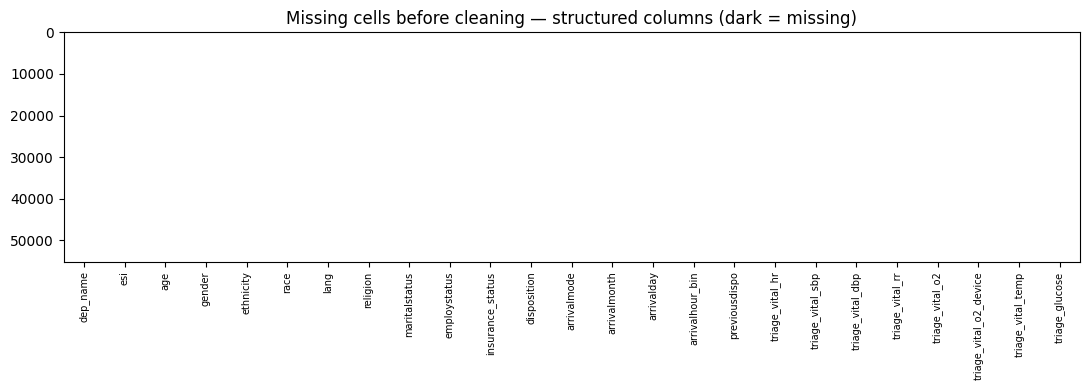

In [15]:
src = (raw if raw is not None else df)
structured = [c for c in src.columns if not c.startswith("cc_")]

fig, ax = plt.subplots(figsize=(11,4))
ax.imshow(src[structured].isna().values, aspect="auto", cmap="gray_r")
ax.set_xticks(range(len(structured)))
ax.set_xticklabels(structured, rotation=90, fontsize=7)
ax.set_title("Missing cells before cleaning — structured columns (dark = missing)")
plt.tight_layout(); plt.savefig("figs/01_missingness.png", dpi=110); plt.show()

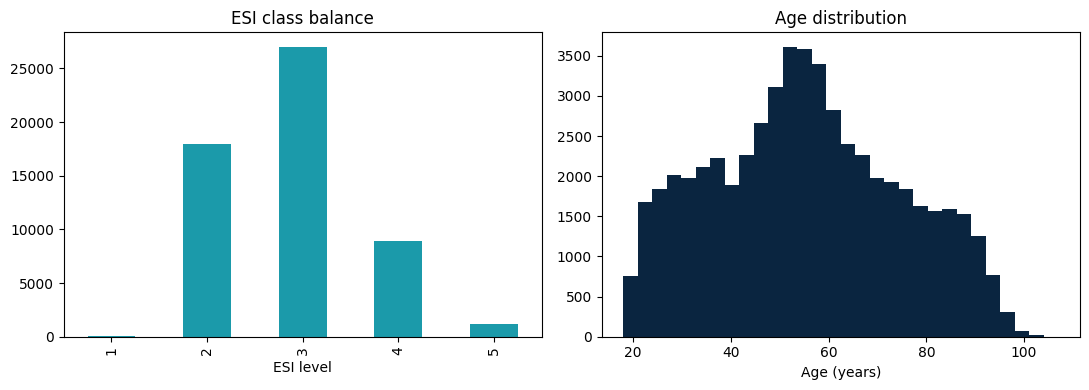

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))

esi_counts = df[TARGET].value_counts().sort_index()
esi_counts.plot.bar(ax=ax[0], color="#1B9AAA")
ax[0].set_title("ESI class balance"); ax[0].set_xlabel("ESI level")

ax[1].hist(df["age"], bins=30, color="#0A2540")
ax[1].set_title("Age distribution"); ax[1].set_xlabel("Age (years)")

plt.tight_layout(); plt.savefig("figs/02_esi_age.png", dpi=110); plt.show()

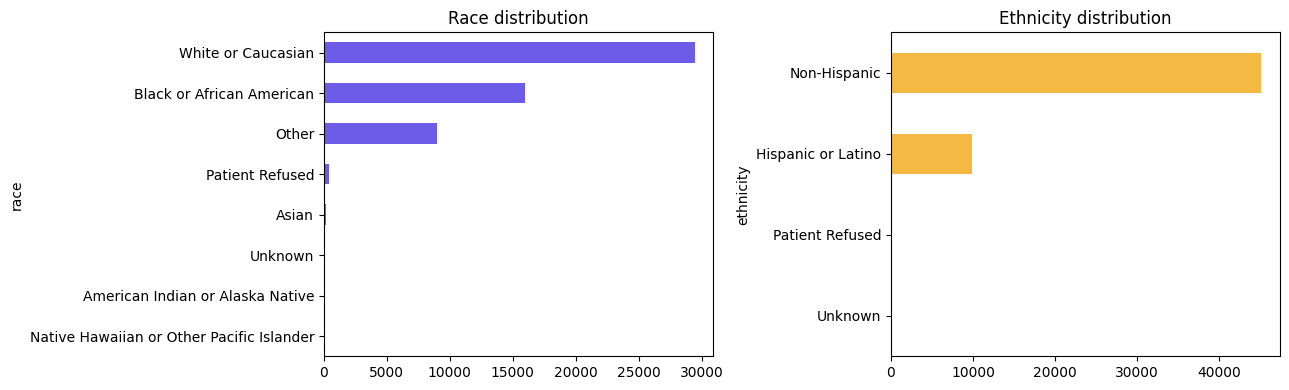

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))

df["race"].value_counts().plot.barh(ax=ax[0], color="#6C5CE7")
ax[0].set_title("Race distribution"); ax[0].invert_yaxis()

df["ethnicity"].value_counts().plot.barh(ax=ax[1], color="#F4B942")
ax[1].set_title("Ethnicity distribution"); ax[1].invert_yaxis()

plt.tight_layout(); plt.savefig("figs/03_demographics.png", dpi=110); plt.show()

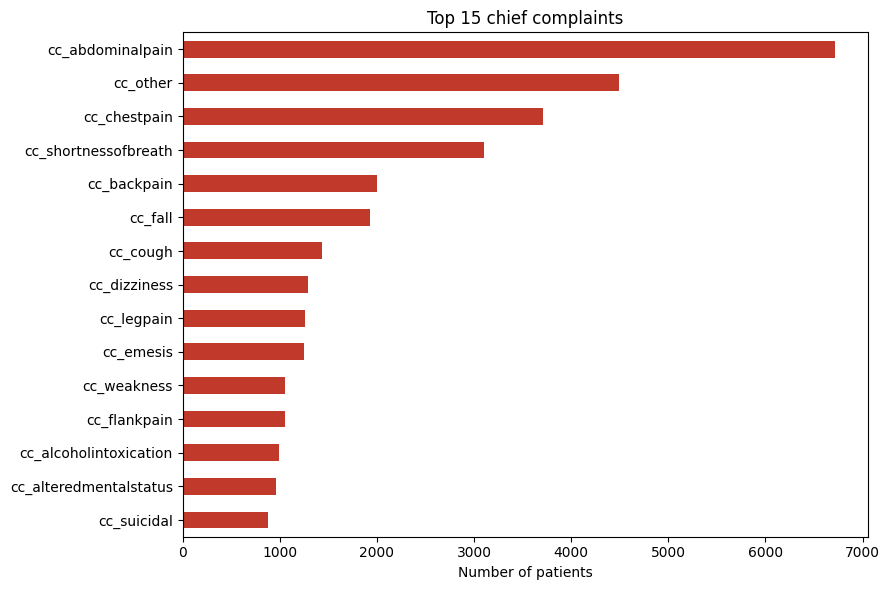

In [18]:
top15 = df[fam["chief_complaints"]].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9,6))
top15[::-1].plot.barh(ax=ax, color="#C0392B")
ax.set_title("Top 15 chief complaints"); ax.set_xlabel("Number of patients")

plt.tight_layout(); plt.savefig("figs/04_chief_complaints.png", dpi=110); plt.show()

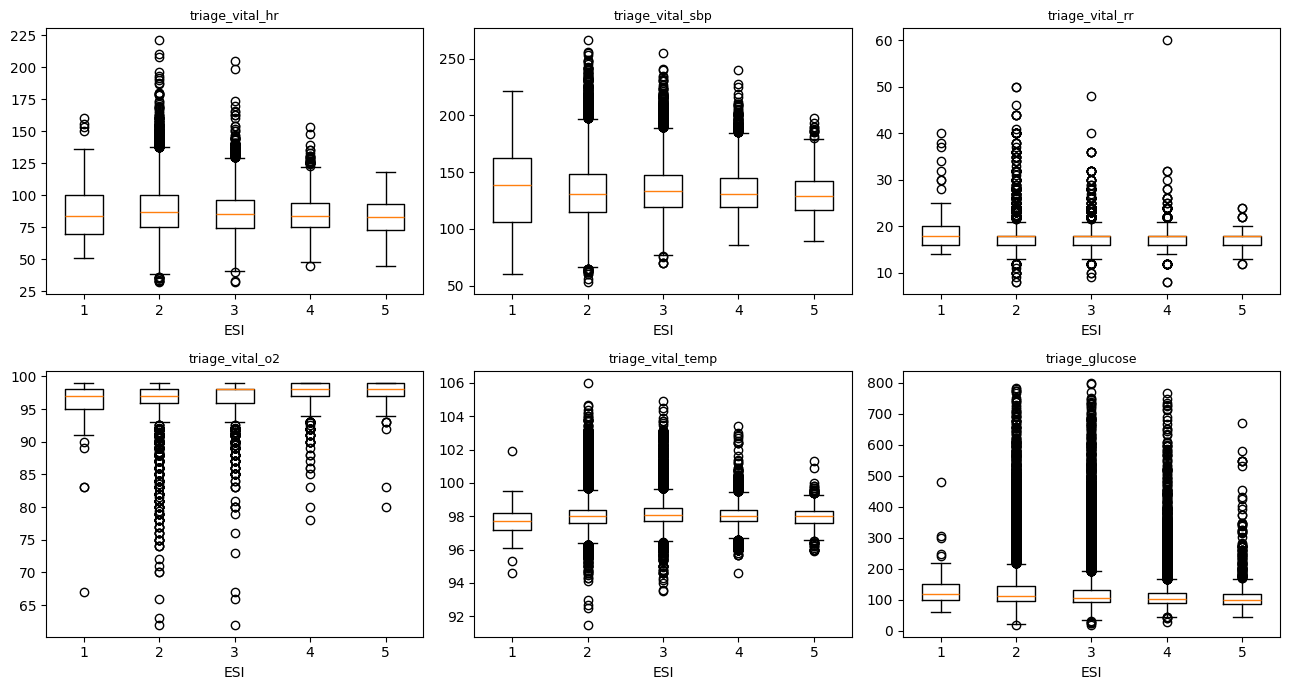

In [19]:
vitals_to_plot = ["triage_vital_hr","triage_vital_sbp","triage_vital_rr",
                  "triage_vital_o2","triage_vital_temp","triage_glucose"]
esi_levels = sorted(df[TARGET].unique())
fig, axes = plt.subplots(2, 3, figsize=(13,7))
for panel, col in zip(axes.ravel(), vitals_to_plot):
    groups = [df.loc[df[TARGET] == level, col] for level in esi_levels]
    panel.boxplot(groups, tick_labels=[int(l) for l in esi_levels])
    panel.set_title(col, fontsize=9); panel.set_xlabel("ESI")
plt.tight_layout(); plt.savefig("figs/05_vitals_by_esi.png", dpi=110); plt.show()

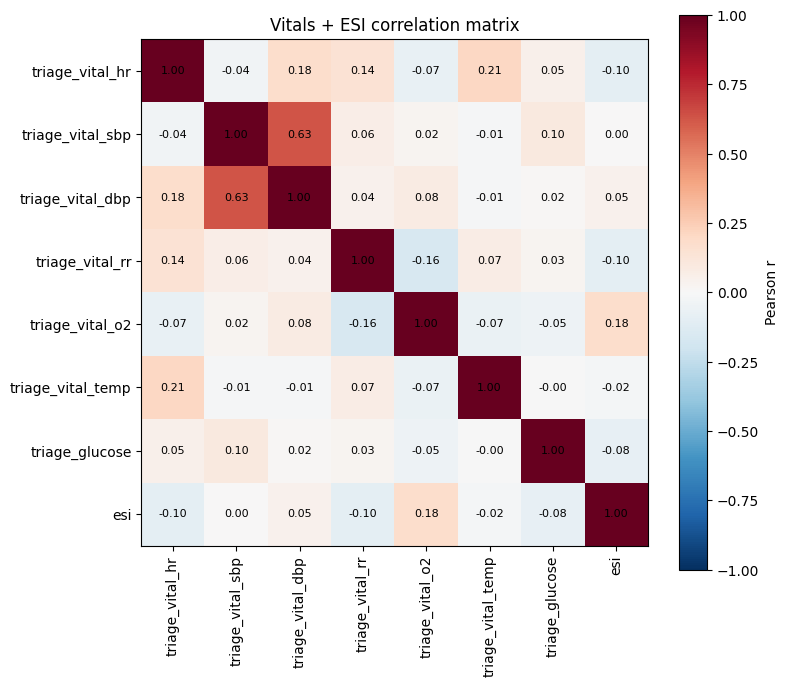

In [20]:
cols = fam["vitals"] + [TARGET]
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i_ in range(len(cols)):
    for j_ in range(len(cols)):
        ax.text(j_, i_, f"{corr.iloc[i_, j_]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Vitals + ESI correlation matrix")

plt.tight_layout(); plt.savefig("figs/06_correlation.png", dpi=110); plt.show()

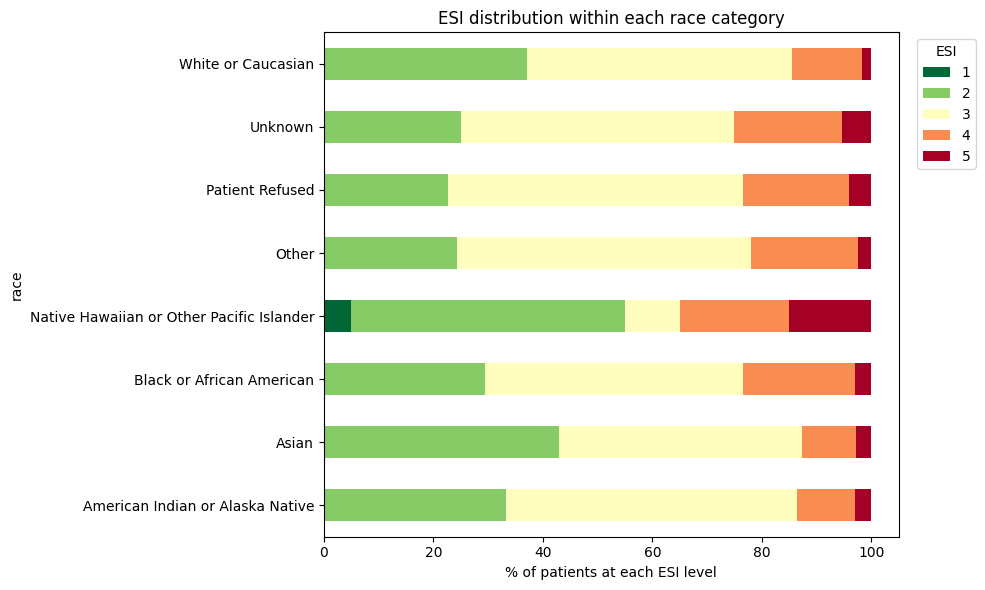

In [21]:
# Exercise 4 — equity plot: ESI distribution within each race category
esi_by_race = pd.crosstab(df["race"], df[TARGET], normalize="index") * 100

fig, ax = plt.subplots(figsize=(10,6))
esi_by_race.plot.barh(stacked=True, ax=ax, colormap="RdYlGn_r")
ax.set_xlabel("% of patients at each ESI level"); ax.set_title("ESI distribution within each race category")
ax.legend(title="ESI", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.savefig("figs/07_equity_esi_by_race.png", dpi=110); plt.show()

## 7 · Top-10 feature shortlist (Task 3)
Ranked by simple correlation with `esi` (sign flipped so higher = more predictive of *higher acuity*, since ESI 1 is most urgent) plus clinical reasoning. Full one-sentence justification for each feature is in the feasibility memo.

In [22]:
shortlist_cols = ["arrivalmode", "age", "triage_vital_o2", "cc_chestpain", "cc_shortnessofbreath",
                  "cc_suicidal", "cc_alteredmentalstatus", "triage_vital_rr", "triage_vital_hr", "triage_glucose"]

d = df.copy()
d["arrived_by_ambulance"] = (d["arrivalmode"] == "ambulance").astype(int)
numeric_shortlist = [c for c in shortlist_cols if c != "arrivalmode"] + ["arrived_by_ambulance"]

corr_to_esi = d[numeric_shortlist].corrwith(d[TARGET])
# Flip sign so positive = 'higher values -> more urgent (lower ESI)', since esi runs 1 (urgent) -> 5 (not urgent).
# triage_vital_o2 is the one exception worth reading carefully: LOW oxygen predicts urgency, so its
# correlation-with-acuity is negative even though it's a top-3 feature by strength.
corr_to_acuity = (-corr_to_esi)
ranked = corr_to_acuity.reindex(corr_to_acuity.abs().sort_values(ascending=False).index)
print("Feature vs. acuity, ranked by strength (sign shows direction: + = higher value -> more urgent):")
print(ranked.round(3))

Feature vs. acuity, ranked by strength (sign shows direction: + = higher value -> more urgent):
arrived_by_ambulance      0.305
age                       0.237
triage_vital_o2          -0.178
cc_chestpain              0.164
cc_shortnessofbreath      0.150
cc_suicidal               0.143
cc_alteredmentalstatus    0.132
triage_vital_rr           0.097
triage_vital_hr           0.095
triage_glucose            0.078
dtype: float64


### A note on rare, high-specificity danger signals

Simple correlation ranks the shortlist above by how well a feature tracks acuity **across the whole population**. That underweights complaints which are almost perfectly predictive of the single rarest, most critical class (ESI-1) but too rare overall to move a population-wide correlation coefficient. Section 9 below digs into exactly that blind spot.

## 9 · ESI-1 deep dive — which complaints actually define the most-urgent patients?

Only 77 of 55,121 patients are ESI-1. A feature that is only lightly correlated with `esi` overall can still be the single strongest signal *for this rarest class* if it's concentrated almost entirely inside it. We check that here with **lift** — the % of ESI-1 patients carrying a flag, divided by the % of all patients carrying it — rather than population-wide correlation.

In [23]:
esi1 = df[df[TARGET] == 1]
print(f"N ESI-1 patients: {len(esi1)} of {len(df):,} ({len(esi1)/len(df)*100:.2f}%)")

overall_prev = df[fam["chief_complaints"]].mean() * 100
esi1_prev = esi1[fam["chief_complaints"]].mean() * 100
lift = (esi1_prev / overall_prev.replace(0, np.nan)).sort_values(ascending=False)

summary = pd.DataFrame({"esi1_pct": esi1_prev, "overall_pct": overall_prev, "lift_x": lift})
summary = summary[summary["esi1_pct"] >= 1.3].sort_values("lift_x", ascending=False)
print("\nChief complaints over-represented in ESI-1 (sorted by lift):")
print(summary.round(2))

# Same signal, two more ways to read it — raw counts (so you can see how thin the evidence is)
# and the reverse question: 'of everyone with this flag, what fraction are ESI-1?'
baseline_esi1_rate = len(esi1) / len(df) * 100
detail = []
for c in summary.head(7).index:
    n_esi1 = int(esi1[c].sum())
    n_total = int(df[c].sum())
    pct_flagged_is_esi1 = n_esi1 / n_total * 100 if n_total else float("nan")
    detail.append([c, n_esi1, len(esi1), n_total, round(pct_flagged_is_esi1, 1)])
detail = pd.DataFrame(detail, columns=["complaint", "n_esi1_with_flag", "n_esi1_total",
                                        "n_all_patients_with_flag", "%_of_flagged_who_are_ESI1"])
print(f"\nBaseline: only {baseline_esi1_rate:.2f}% of ALL patients are ESI-1.")
print("So if a complaint had no link to acuity, ~0.14% of its flagged patients would be ESI-1:\n")
print(detail.to_string(index=False))

N ESI-1 patients: 77 of 55,121 (0.14%)

Chief complaints over-represented in ESI-1 (sorted by lift):
                        esi1_pct  overall_pct  lift_x
cc_strokealert             29.87         0.09  316.63
cc_respiratorydistress      5.19         0.03  150.71
cc_unresponsive             3.90         0.06   65.08
cc_hypotension              6.49         0.36   17.99
cc_neurologicproblem        5.19         0.52   10.01
cc_alteredmentalstatus      3.90         1.74    2.24
cc_shortnessofbreath       10.39         5.62    1.85
cc_other                    9.09         8.15    1.12
cc_dizziness                2.60         2.34    1.11
cc_backpain                 3.90         3.62    1.08
cc_chestpain                5.19         6.73    0.77
cc_fall                     2.60         3.49    0.74

Baseline: only 0.14% of ALL patients are ESI-1.
So if a complaint had no link to acuity, ~0.14% of its flagged patients would be ESI-1:

             complaint  n_esi1_with_flag  n_esi1_total  n_a

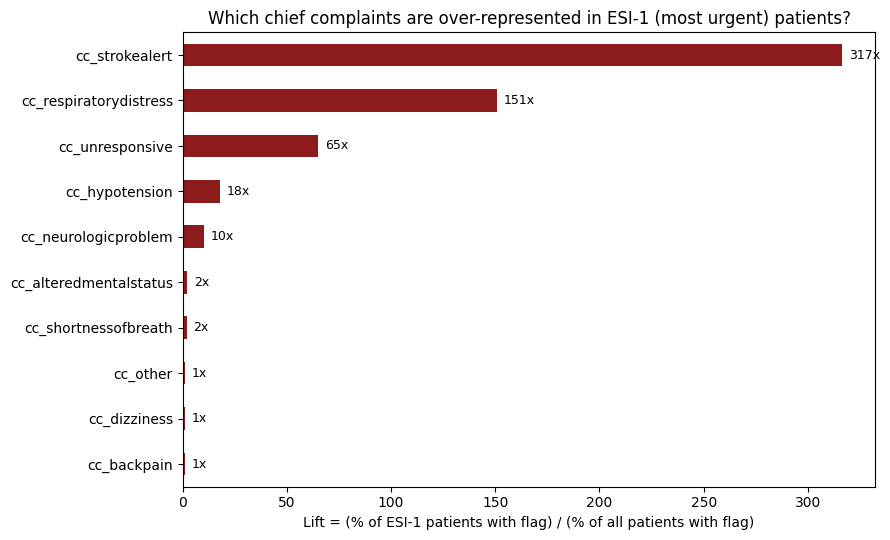

In [24]:
top = summary["lift_x"].head(10)

fig, ax = plt.subplots(figsize=(9,5.5))
top[::-1].plot.barh(ax=ax, color="#8E1B1B")
ax.set_xlabel("Lift = (% of ESI-1 patients with flag) / (% of all patients with flag)")
ax.set_title("Which chief complaints are over-represented in ESI-1 (most urgent) patients?")
for i, (name, val) in enumerate(top[::-1].items()):
    ax.text(val + top.max()*0.01, i, f"{val:.0f}x", va="center", fontsize=9)
plt.tight_layout(); plt.savefig("figs/08_esi1_complaint_lift.png", dpi=110); plt.show()

In [25]:
# Do ESI-1 patients also look different on vitals and mode of arrival?
vitals_compare = pd.DataFrame({
    "esi1_mean": esi1[fam["vitals"]].mean(),
    "overall_mean": df[fam["vitals"]].mean(),
}).round(1)
print("Vitals: ESI-1 mean vs. overall mean")
print(vitals_compare)

print(f"\nAmbulance arrival — ESI-1: {(esi1['arrivalmode']=='ambulance').mean()*100:.1f}%"
      f"   |   overall: {(df['arrivalmode']=='ambulance').mean()*100:.1f}%")

Vitals: ESI-1 mean vs. overall mean
                   esi1_mean  overall_mean
triage_vital_hr         90.0          86.4
triage_vital_sbp       134.9         133.7
triage_vital_dbp        78.5          79.5
triage_vital_rr         19.7          17.8
triage_vital_o2         95.8          97.0
triage_vital_temp       97.7          98.1
triage_glucose         137.8         129.8

Ambulance arrival — ESI-1: 76.6%   |   overall: 33.7%


**Reading this.** ESI-1 is dominated by a handful of protocol-trigger complaints — `cc_strokealert` alone appears in ~30% of ESI-1 patients versus 0.09% of everyone else (a ~317x lift), and `cc_respiratorydistress`, `cc_unresponsive`, and `cc_hypotension` show similarly extreme concentration. By contrast, mean vitals for ESI-1 patients are only modestly different from the overall population (e.g. HR 90 vs. 86, oxygen saturation 95.8% vs. 97.0%) — nowhere near as sharp a signal as the complaint flags. Ambulance arrival is the exception among the continuous/structured fields: 76.6% of ESI-1 patients arrive by ambulance vs. 33.7% overall.

**Why these complaints don't show up in the Section 7 shortlist:** a feature that fires on 52 patients total (`cc_strokealert`) can't move a population-wide Pearson correlation much, no matter how concentrated its effect is in that group. The Section 7 shortlist is the right list for separating the *broad* acuity gradient (ESI 2 vs. 3 vs. 4). For flagging the rarest, highest-stakes class specifically, a short list of named protocol-trigger complaints (stroke alert, respiratory distress, hypotension, unresponsive) plus ambulance arrival should be added as engineered features for Week 6, evaluated on recall for ESI-1 specifically rather than overall accuracy.

**On padding ESI-1 with synthetic data:** with only 77 real patients spread across ~200 sparse binary complaint columns, generating synthetic rows (even via SMOTE-style interpolation) risks inventing physiologically incoherent patients — e.g. a synthetic `cc_strokealert=1` row with unremarkable vitals that no real stroke-alert patient resembles. That's a clinical-plausibility risk, not just a modelling nitpick, for a classifier meant to support triage. Class weighting, stratified evaluation, and cost-sensitive metrics (recall on ESI-1 specifically) are the safer route for Week 6 — they respect that every ESI-1 label in this dataset is a real patient, without asking the model to learn from patients who don't exist.

**Caveat — small-sample noise.** Some of these counts are tiny: `cc_unresponsive` and `cc_neurologicproblem` are each based on only 3-4 ESI-1 patients. One patient more or fewer would swing the percentage by roughly a third. Treat the *ranking* (stroke alert clearly dominates, then a steep drop-off) as solid — don't treat the precise multiplier ("65x" vs "50x") as a stable estimate with this few patients.


## 10 · Conclusion
**Verdict: proceed to Week 6 baseline modelling, with caveats.** The dataset is large (55,121 rows), has zero missingness in structured fields, and its strongest broad-acuity features (ambulance arrival, age, oxygen saturation, chest pain / shortness-of-breath flags) line up with clinical intuition. Section 9 adds an important refinement: the rarest, most critical class (ESI-1) is defined less by vital-sign magnitude and more by a small set of protocol-trigger complaints (stroke alert, respiratory distress, hypotension, unresponsive) plus ambulance arrival — worth engineering as explicit features for Week 6, and worth evaluating with class-specific recall rather than only overall accuracy. The remaining caveats — sparse chief-complaint flags, single-country/3-department sourcing, and a measurable race gap in ESI-4 assignment rates — are documented in the issues table above and carried into the feasibility memo's caveats section.